In [1]:
import pandas as pd 
import numpy as np 

np.random.seed(42)          
n = 500 
df = pd.DataFrame({ 
'CustomerID': range(1, n + 1),  
'Age': np.random.randint(18, 70, n),   
'Region': np.random.choice(['North', 'South', 'East', 'West'], n),    
'Income' : np.random.randint(20000, 150000, n),   
'Purchases': np.random.poisson(5, n), 
'Member_Years' : np.random.randint(0, 10, n), 
'Satisfaction' : np.random.randint(1, 11, n) 
})
df

,CustomerID,Age,Region,Income,Purchases,Member_Years,Satisfaction
0,1,56,West,142418,4,2,4
1,2,69,North,63088,4,0,1
2,3,46,East,136868,4,2,1
3,4,32,West,123196,7,2,5
4,5,60,East,59811,6,3,2
...,...,...,...,...,...,...,...
495,496,65,East,69688,6,9,6
496,497,42,West,119929,5,8,2
497,498,57,South,128618,2,6,4
498,499,62,East,93509,7,1,7


In [2]:
# Introduce a few realistic problems to find and fix:

df.loc[np.random.choice(df.index, 15, replace=False), 'Income'] = np.nan 
df = pd.concat([df, df.sample(5, random_state=1)], ignore_index=True) 
df

,CustomerID,Age,Region,Income,Purchases,Member_Years,Satisfaction
0,1,56,West,142418.0,4,2,4
1,2,69,North,63088.0,4,0,1
2,3,46,East,136868.0,4,2,1
3,4,32,West,NaN,7,2,5
4,5,60,East,59811.0,6,3,2
...,...,...,...,...,...,...,...
500,305,36,North,78596.0,4,4,3
501,341,37,South,31246.0,8,1,3
502,48,35,West,48732.0,5,6,8
503,68,57,West,148077.0,4,0,2


PART A

In [3]:
# Write a function calculate_clv(row) that estimates each customer's rough lifetime value as Purchases × Member_Years × 15, using conditionals and arithmetic

def calculate_clv(row):
    if row["Purchases"]>0 and row["Member_Years"]>0:
        return row["Purchases"] * row["Member_Years"] * 15

    else:
        return 0

# Apply the function to create a new CLV column using a .apply()

df["CLV"]=df.apply(calculate_clv, axis=1)
df

,CustomerID,Age,Region,Income,Purchases,Member_Years,Satisfaction,CLV
0,1,56,West,142418.0,4,2,4,120
1,2,69,North,63088.0,4,0,1,0
2,3,46,East,136868.0,4,2,1,120
3,4,32,West,NaN,7,2,5,210
4,5,60,East,59811.0,6,3,2,270
...,...,...,...,...,...,...,...,...
500,305,36,North,78596.0,4,4,3,240
501,341,37,South,31246.0,8,1,3,120
502,48,35,West,48732.0,5,6,8,450
503,68,57,West,148077.0,4,0,2,0


PART B

In [4]:
# Missing Values

print(f"The missing values are :\n{df.isnull().sum()}")
print("-"*30)

print(f"The Total missing values :{df.isnull().sum().sum()}")
print("-"*30)

# dispaly the duplicate rows
print(df[df.duplicated()])
print("-"*30)

print(f"The Total duplicate rows is:{df.duplicated().sum()}")




The missing values are :
CustomerID       0
Age              0
Region           0
Income          15
Purchases        0
Member_Years     0
Satisfaction     0
CLV              0
dtype: int64
------------------------------
The Total missing values :15
------------------------------
     CustomerID  Age Region    Income  Purchases  Member_Years  Satisfaction  \
500         305   36  North   78596.0          4             4             3   
501         341   37  South   31246.0          8             1             3   
502          48   35   West   48732.0          5             6             8   
503          68   57   West  148077.0          4             0             2   
504         480   47  South  139719.0          3             9             9   

     CLV  
500  240  
501  120  
502  450  
503    0  
504  405  
------------------------------
The Total duplicate rows is:5


In [5]:
# Handle the missing Income values using median imputation
df["Income"]=df["Income"].fillna(df["Income"].median())
df

                    # JUSTIFICATION
# The median is used because it is less affected by outliers,
# making it a better choice for income data, which is often skewed.

,CustomerID,Age,Region,Income,Purchases,Member_Years,Satisfaction,CLV
0,1,56,West,142418.0,4,2,4,120
1,2,69,North,63088.0,4,0,1,0
2,3,46,East,136868.0,4,2,1,120
3,4,32,West,87475.0,7,2,5,210
4,5,60,East,59811.0,6,3,2,270
...,...,...,...,...,...,...,...,...
500,305,36,North,78596.0,4,4,3,240
501,341,37,South,31246.0,8,1,3,120
502,48,35,West,48732.0,5,6,8,450
503,68,57,West,148077.0,4,0,2,0


In [6]:
# To Remove duplicate rows and confirm the new shape of the DataFrame

df=df.drop_duplicates(subset="CustomerID",keep="first")
df.shape

(500, 8)

PART C

In [7]:
df.describe()

,CustomerID,Age,Income,Purchases,Member_Years,Satisfaction,CLV
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,44.220000,85065.764000,5.056000,4.620000,5.576000,346.260000
std,144.481833,15.036082,39456.950987,2.271383,2.806306,2.816396,278.751353
min,1.000000,18.000000,20055.000000,0.000000,0.000000,1.000000,0.000000
25%,125.750000,32.000000,48723.750000,3.000000,2.000000,3.000000,120.000000
50%,250.500000,45.000000,87475.000000,5.000000,5.000000,6.000000,270.000000
75%,375.250000,57.000000,120915.000000,7.000000,7.000000,8.000000,525.000000
max,500.000000,69.000000,149922.000000,12.000000,9.000000,10.000000,1350.000000


In [8]:
Average=df.groupby("Region")[["Income","Satisfaction"]].agg("mean")
Average.columns=["Average_Income","Average_Satisfaction"]
Average

,Average_Income,Average_Satisfaction
Region,,
East,88154.752212,5.646018
North,80310.241611,5.382550
South,83591.619835,5.710744
West,89663.102564,5.615385


In [9]:
df["Age_Band"]=pd.cut(df["Age"],bins=[0,29,50,float("inf")],labels=["Under 30","30_50","Over 50"])

# Create Pivot Table

pivot=df.pivot_table(values="Purchases",
               index="Region",
               columns="Age_Band",
               aggfunc="mean")
pivot

Age_Band,Under 30,30_50,Over 50
Region,,,
East,4.523810,5.409091,5.020833
North,4.606061,5.163636,5.098361
South,5.586207,4.719298,5.514286
West,4.708333,5.039216,5.071429


PART D

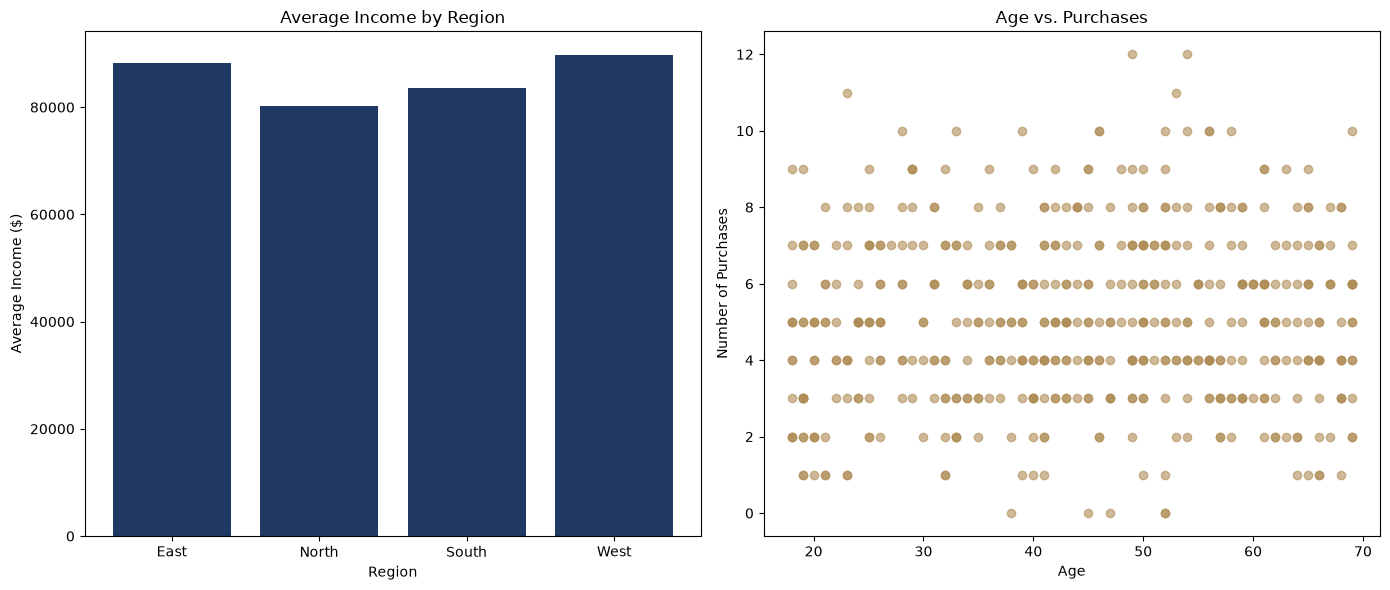

In [10]:
import matplotlib.pyplot as plt 
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

# Left subplot: bar chart 
region_income = df.groupby('Region')['Income'].mean() 
axes[0].bar(region_income.index, region_income.values, color='#1F3864') 
axes[0].set_title('Average Income by Region') 
axes[0].set_xlabel('Region') 
axes[0].set_ylabel('Average Income ($)') 

# Right subplot: scatter plot 
axes[1].scatter(df['Age'], df['Purchases'], alpha=0.6, c='#B08D57') 
axes[1].set_title('Age vs. Purchases') 
axes[1].set_xlabel('Age') 
axes[1].set_ylabel('Number of Purchases')

plt.tight_layout() 
plt.savefig('capstone_dashboard.png', dpi=150) 
plt.show()

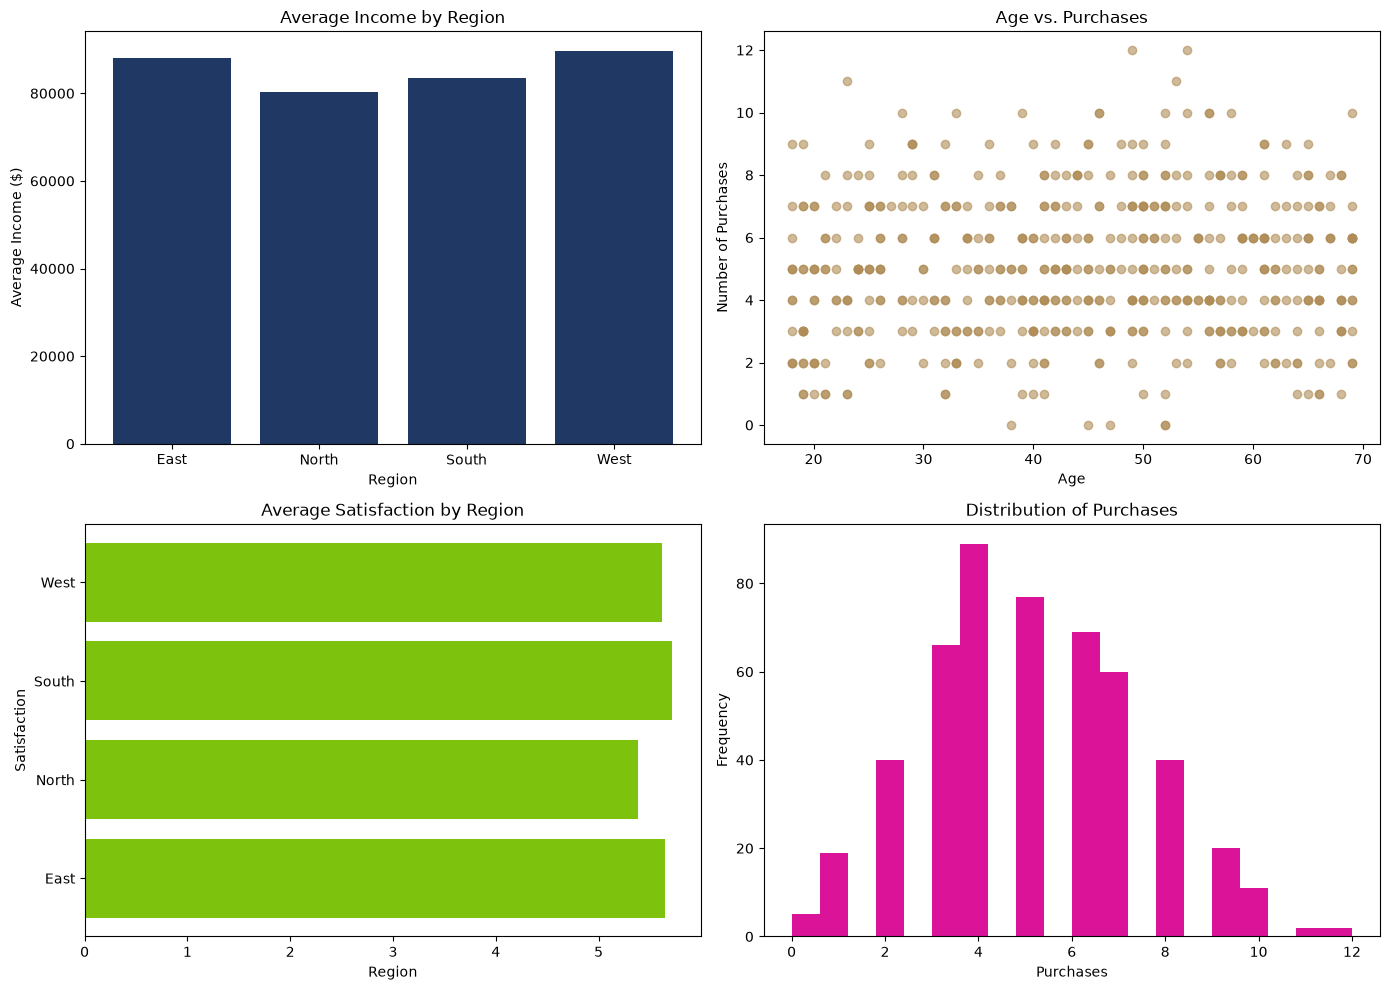

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) 

# 1. Average Income by Region 
region_income = df.groupby('Region')['Income'].mean() 

axes[0,0].bar(region_income.index, region_income.values, color='#1F3864') 
axes[0,0].set_title('Average Income by Region') 
axes[0,0].set_xlabel('Region') 
axes[0,0].set_ylabel('Average Income ($)') 

# 2. Age vs Purchases 
axes[0,1].scatter(df['Age'], df['Purchases'], alpha=0.6, c='#B08D57') 
axes[0,1].set_title('Age vs. Purchases') 
axes[0,1].set_xlabel('Age') 
axes[0,1].set_ylabel('Number of Purchases')

# 3. Average Satisfaction by Region
avg_sat = df.groupby("Region")["Satisfaction"].mean()

axes[1,0].barh(avg_sat.index, avg_sat.values, color="#7DC20D")
axes[1,0].set_title("Average Satisfaction by Region")
axes[1,0].set_xlabel("Region")
axes[1,0].set_ylabel("Satisfaction")

# 4. Purchases Distribution
axes[1,1].hist(df["Purchases"], bins=20,color="#DB1398")
axes[1,1].set_title("Distribution of Purchases")
axes[1,1].set_xlabel("Purchases")
axes[1,1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("capstone_dashboard.png", dpi=300)
plt.show()



PART E

In [12]:
# Correlation between Income and Satisfaction
corr1=df["Income"].corr (df["Satisfaction"])

# Correlation between Member_Years and CLV
corr2=df["Member_Years"].corr(df["CLV"])

print(f"The Correlation between Income and Satisfaction is:{corr1:.3f}")
print(f"The Correlation Member_Years and CLV is:{corr2:.3f}")

print("-"*50)

# Split customer into two groups
High_Sat=df[df["Satisfaction"]>7]["Income"]
Low_Sat=df[df["Satisfaction"]<7]["Income"]

# Independent-samples t-test 
from scipy.stats import ttest_ind

T_stat,P_value=ttest_ind(High_Sat,Low_Sat)
print(f"T_Statistics:{T_stat:.3f}")
print(f"P_value:{P_value:.4f}")



The Correlation between Income and Satisfaction is:-0.013
The Correlation Member_Years and CLV is:0.756
--------------------------------------------------
T_Statistics:-0.213
P_value:0.8315


In [13]:
# Interpreting the Results

# Since the p-value (0.8315) is greater than 0.05,
# the difference in Income between customers with
# Satisfaction >= 7 and Satisfaction < 7 is not statistically significant.
# This means there is no strong evidence that customer satisfaction 
# is associated with a difference in average income.

 PLAIN ENGLISH EXPLANATION

An independent-samples t-test was conducted to compare the average income of customers with satisfaction scores of 7 or higher and those with scores below 7. The test produced a t-statistic of -0.213 and a p-value of 0.8315. Since the p-value is greater than the 0.05 significance level, the difference is not statistically significant. This indicates that any observed difference in average income between the two groups is likely due to chance rather than a real difference in the population.